# Lecture 06

## Fitting a line to data


Continuing the theme of last lecture, let's look at one of the most common tasks in statistical inference: **fitting a line to data**. We won't always fit a straight line, but they are prevalent in astronomy since we're potentially examining data over several orders of magnitude. Hence power-law relationships ($y \propto x^\alpha$) become linear relationships in log-log space ($\ln y \propto \alpha \ln x + \text{constant}$).

Assume the noise/scatter in our measurements (the residuals) is generated by a Gaussian process, i.e.:

$$y_i = ax_i + b + r_i$$

where $r_i$ is drawn from $N(0, \sigma)$. Here, $\sigma$ is the measurement uncertainty, which we take to be the same for all points. The data model includes a linear relationship with two parameters $a, b$: hence the model is written as $M(a, b)$.

Let us compute the likelihood. First, we ask ourselves what is the probability $p(y_i|x_i, M(a, b), \sigma)$ that a particular point $y_i$ would be measured. It is just the normal distribution:

$$p(y_i|x_i, M(a, b), \sigma) = N(y_i - M(x_i)|\sigma) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( - \frac{(y_i - M(x_i))^2}{2\sigma^2} \right).$$

The likelihood for all data points is given by the product over $N$ of these terms. Given our previous definitions we can then write down the $\ln L$ as

$$\ln L(a, b) = \text{constant} - \frac{1}{2} \sum_{i=1}^N \frac{(y_i - M(x_i))^2}{\sigma^2} = \text{constant} - \frac{1}{2}\chi^2$$

This is the expression that we now **maximize** with respect to $a$ and $b$ to find ML estimators for those parameters. This is equivalent to **minimizing** the sum of the squares (the $\chi^2$) in a *least-squares method*.

## Outliers Managment

A standard approach is also changing the **likelihood** to reduce the weight of outliers. This is known as the **Huber loss function**

$$\sum_{i=1}^N e(y_i|y),$$

where

$$ e(t) = \begin{cases} 
\frac{1}{2}t^2 & \text{if } |t| \le c, \\ 
c|t| - \frac{1}{2}c^2 & \text{if } |t| \ge c, 
\end{cases} $$

and

$$t = \left| \frac{y - M(x)}{\sigma} \right|.$$

This is continuous and differentiable, and transitions to an $L_1$ norm ($\sum_{i=1}^N |y_i - M(x_i)|$) for large data excursions, which downweights the outlier points.

* Alternatively, using interquartile ranges, taking the median of solutions of subsets of the data, and least trimmed squares (which searches for the subset of points that minimizes $\sum_i^N (y_i - \theta_i x_i)^2$), or modern machine-learning solutions like RANSAC.



In [1]:
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format='retina'

import scipy.stats
from scipy.stats import norm
from scipy.stats import uniform
from scipy import optimize
from astroML import stats as astroMLstats
from astroML.datasets import fetch_hogg2010test

data = fetch_hogg2010test()
x = data['x'] 
y = data['y'] 
dy = data['sigma_y'] 

def squared_loss(m, b, x, y, dy):
    y_fit = m * x + b
    return np.sum(((y - y_fit) / dy) ** 2, -1)

# define a lambda function that defines the sum of squared errors, both with and without outliers
f_squared = lambda beta: squared_loss(beta[0], beta[1], 
                                      x=x[4:], y=y[4:], 
                                      dy=dy[4:])
beta0 = (1, 30)
beta_mle = optimize.fmin(f_squared, beta0)

f_squared = lambda beta: squared_loss(beta[0], beta[1], 
                                      x=x, y=y, 
                                      dy=dy)

beta0 = (1, 30) # initial guess for a and b
beta_mle_outlier = optimize.fmin(f_squared, beta0)


# Define the log-likelihood via the Huber loss function
def huber_loss(m, b, x, y, dy, c=1):
    y_fit = m * x + b # model
    t = abs((y - y_fit) / dy)
    mask = t > c # define mask for large excursion points
    return np.sum(np.logical_not(mask) * (0.5 * t ** 2) - \
                  (mask) * c * (0.5 * c - t), -1)

c=1

# lambda function for huber loss 
f_huber = lambda beta: huber_loss(beta[0], beta[1], 
                                  x=x, y=y, dy=dy, c=c)

# compute the maximum likelihood using the huber loss
beta0 = (1, 30)
beta_huber = optimize.fmin(f_huber, beta0)

Optimization terminated successfully.
         Current function value: 18.680770
         Iterations: 53
         Function evaluations: 106
Optimization terminated successfully.
         Current function value: 289.963723
         Iterations: 70
         Function evaluations: 133
Optimization terminated successfully.
         Current function value: 43.439758
         Iterations: 62
         Function evaluations: 118


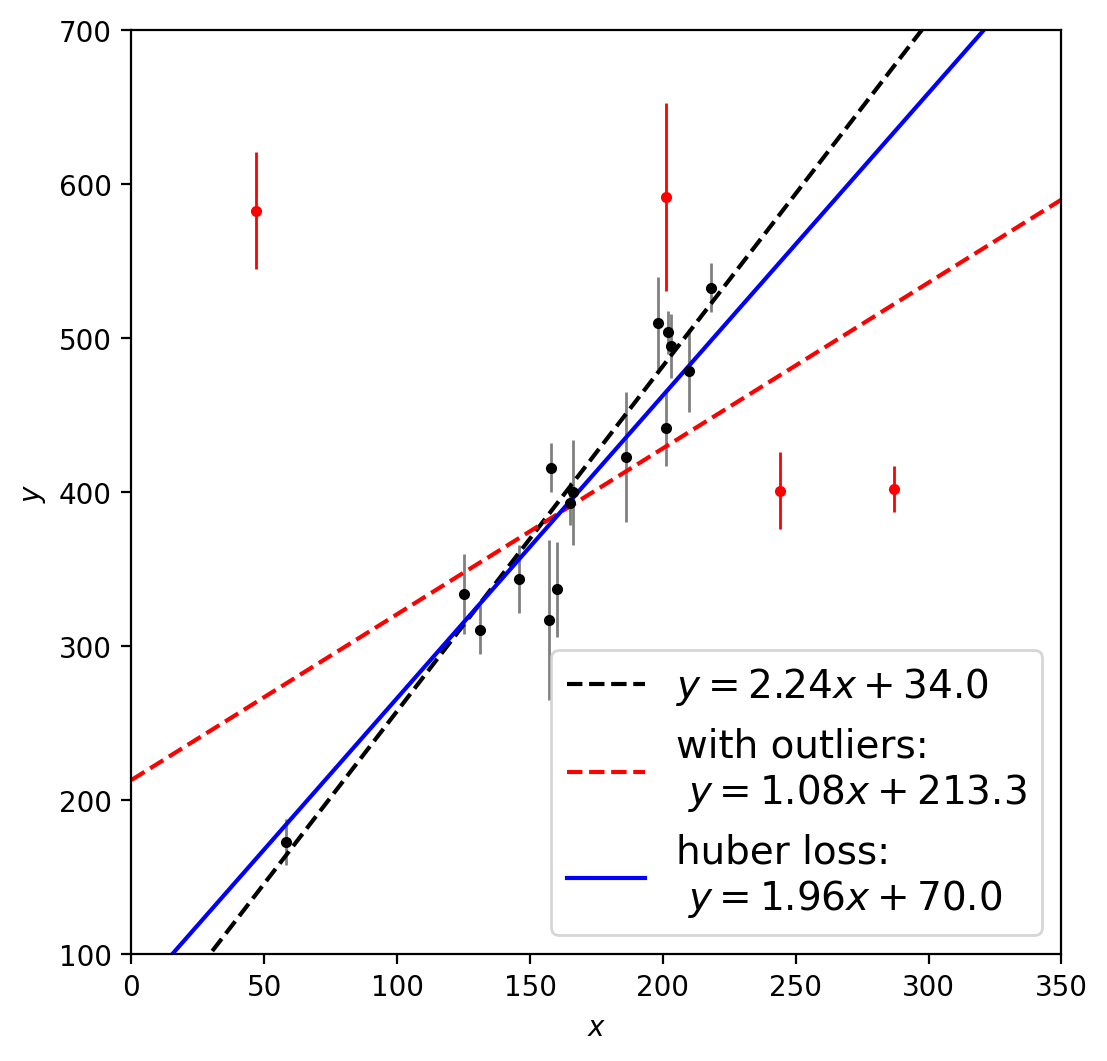

In [2]:
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)

ax.errorbar(x[4:], y[4:], dy[4:], 
            fmt='.k', lw=1, ecolor='gray')
# plot the outliers in red
ax.errorbar(x[:4], y[:4], dy[:4], 
            fmt='.', lw=1, color='red')

x_fit = np.linspace(0, 350, 10)
# plot the regular fit from before without outliers
ax.plot(x_fit, beta_mle[0] * x_fit + beta_mle[1], 
        ls='--', color='k',
        label="$y=%.2fx + %.1f$" % tuple(beta_mle))
# plot the fit that includes outliers
ax.plot(x_fit, beta_mle_outlier[0] * x_fit + beta_mle_outlier[1], 
        ls='--', color='red',
        label="with outliers:\n $y=%.2fx + %.1f$" % tuple(beta_mle_outlier))
# plot the fit with the huber likelihood, downweighting outliers
ax.plot(x_fit, beta_huber[0] * x_fit + beta_huber[1], 
        ls='-', color='blue',
        label="huber loss:\n $y=%.2fx + %.1f$" % tuple(beta_huber))

ax.set_xlim(0, 350)
ax.set_ylim(100, 700)
ax.set_xlabel('$x$')
ax.set_ylabel('$y$')
ax.legend(loc=4, prop=dict(size=14))

plt.show()

Basically we are changing the weight of outliers for our fit by changing the metric associated to compute them (from L2 to L1).\
Giving a much lower weight on those measurment the fit is much less affected

## Goodness of Fit and Model Comparison

We can describe the **goodness of fit** in words as simply the followng

> *The goodness of fit tells us whether or not it is likely to have obtained the maximum (log-)likelihood* $\ln L^0$.

Using the best-fit parameters of a model, the maximum likelihood value $L^0$ should not be an unlikely occurence. If it is, then our model is not describing the data well. Thus we need to know the *distribution* of $\ln L$ and not just its maximum. For the Gaussian case we have just described, we do a standard transform of variables and compute the so-called $z$ score for each data point (basically the number of standard deviations away from the mean that this point is), writing

$$z_i = (x_i - \mu)/\sigma,$$

then

$$\ln L = \text{constant} - \frac{1}{2} \sum_{i=1}^N z_i^2 = \text{constant} - \frac{1}{2}\chi^2.$$

**So for Gaussian uncertainties, $\ln L$ is distributed as $\chi^2$.** 

***The mean of the $\chi^2$ distribution is $N - k$ and its standard deviation is $\sqrt{2(N - k)}$.***

We define the $\chi^2$ per degree of freedom, $\chi^2_{\text{dof}}$, as

$$\chi^2_{\text{dof}} = \frac{1}{N - k} \sum_{i=1}^N z_i^2.$$

where $k$ is the number of model parameters determined from the data.

* For a good fit, we would expect that $\chi^2_{\text{dof}} \approx 1$.
* If $\chi^2_{\text{dof}}$ is significantly larger than 1, or $(\chi^2_{\text{dof}} - 1) \gg \sqrt{2/(N - k)}$, then it is likely that we are not using the correct model.
* If data uncertainties are **(over)under-estimated** then this can lead to improbably **(low)high** $\chi^2_{\text{dof}}$.

In [3]:
# number of data points *without* outliers
N = x[4:].shape[0]
# number of data points *with* outliers
N_outlier = x.shape[0]
# number of model parameters (a,b)
k = 2 

#print(x[4:].shape)

# chi2 per dof *without* outliers
chi2 = squared_loss(beta_mle[0], 
                    beta_mle[1], 
                    x=x[4:], y=y[4:], dy=dy[4:])
chi2dof = chi2 / (N-k)

# chi2 per dof *with* outliers
chi2_outlier = squared_loss(beta_mle_outlier[0], 
                            beta_mle_outlier[1], 
                            x=x, y=y, dy=dy)
chi2dof_outlier = chi2_outlier / (N_outlier - k)

# without outliers
found =  chi2dof-1
expected = np.sqrt(2/(N-k))

print("Without outlier. chi2dof-1:", found, "std:", expected, "Nsigma:", found/expected)

# with outliers
found =  chi2dof_outlier-1
expected = np.sqrt(2/(N_outlier-k))

print("With outlier. chi2dof-1:", found, "std:", expected, "Nsigma:", found/expected)

Without outlier. chi2dof-1: 0.33434070794594706 std: 0.3779644730092272 Nsigma: 0.8845823663902529
With outlier. chi2dof-1: 15.109095710111468 std: 0.3333333333333333 Nsigma: 45.327287130334405


* Can you do this for the fit we've done above with the Huber loss function? Hint: no. Why?\
Because to use the $\chi^2$ i need my residual to be **gaussian**, Huber loss funtion assume outliers to be non gaussian distributied.
* Solution: for non-Gaussian likelihoods we can still rank different models in terms of their respectively computed maximum likelihood values, this is only really fair if the models have the same number of parameters.

In [4]:
# compute a quantity related to lnL0 for the 
# squared loss function
lnL_sq = - squared_loss(beta_mle_outlier[0], 
                        beta_mle_outlier[1], 
                        x=x, y=y, dy=dy)

# compute a quantity related to lnL0 for the 
# Huber loss function
lnL_huber = - huber_loss(beta_huber[0], 
                         beta_huber[1], 
                         x=x, y=y, dy=dy)

print("Maximum log likelihood for squared loss = %.1f" % lnL_sq)
print("Maximum log likelihood for Huber loss = %.1f" % lnL_huber)

Maximum log likelihood for squared loss = -290.0
Maximum log likelihood for Huber loss = -43.4


## Confidence Estimating: Bootstrap y Jackknife

### Bootstrap Method: Sampling with Replacement

In bootstrapping, we map the uncertainty of model parameters by re-sampling from our data (with replacement) $B$ times. This is relatively new (Efron, 1979) and was named in inspiration of "*pulling oneself up by one's bootstraps*".

It's a way of saying that one creates information seemingly out of nothing. Of course that's not the case, but let's see what this is about... We **sample the data with replacements** (yes, there will be duplicates!).

When sampling from observed data of length $N$ with replacement, there are $N!$ distinct combinations of new observed datasets, and there is only a $N!/N^N$ probability of getting back the original dataset (even for $N = 10$ this is only 0.00036).

With $B$ new bootstrap datasets, we compute our statistics on each to obtain $B$ measures of our parameters. So, if we have $i = 1, \dots, N$ data points in $\{x_i\}$, we draw $N$ of them to make a new sample, where some values of $\{x_i\}$ will be used more than once (and this is ok).

**EXAMPLE**

* We have an original dataset of 1000 points drawn from a Gaussian distribution.
* We can only measure the standard deviation of the distribution once with this dataset.
* Our previous strategies showed that we can use a *Fisher estimate* or an *analytic estimate* of the sample standard deviation uncertainty.
* Instead, we use the bootstrap method to resample the data 10,000 times, and compute the standard deviation and $\sigma_G$ on each new dataset.
* This will map out the uncertainty distribution of those statistics, allowing us to quote confidence limits in our actual measured value.

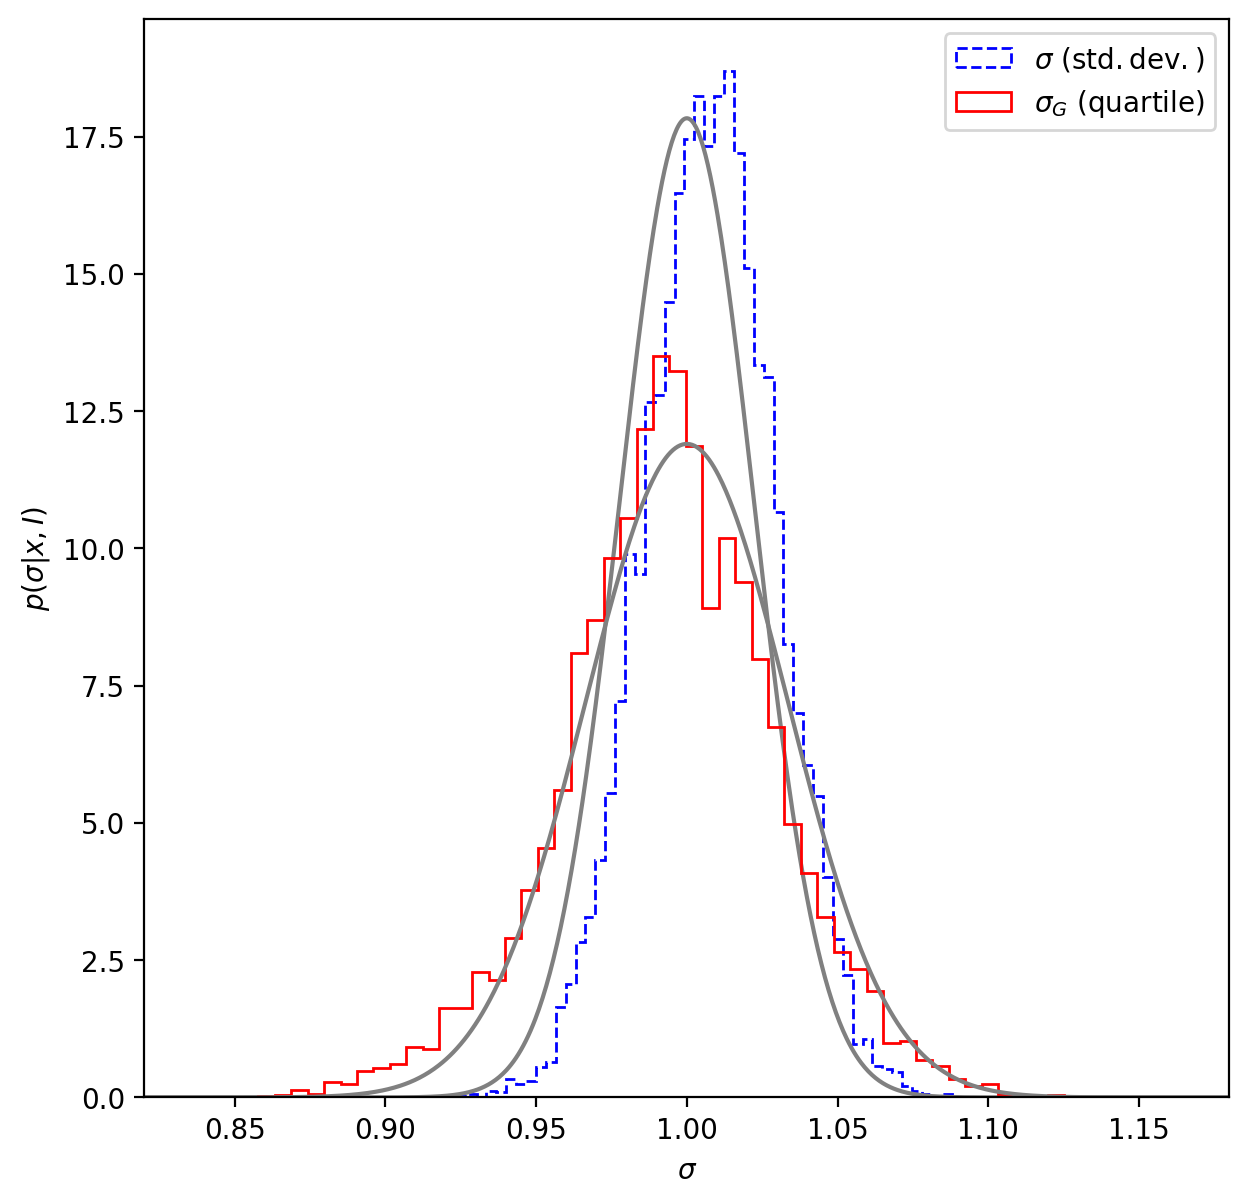

In [5]:
from astroML.resample import bootstrap
from astroML.stats import sigmaG

m = 1000  # number of points
n = 10000  # number of bootstraps

# sample values from a normal distribution
np.random.seed(11)
data = norm(0, 1).rvs(m)

# Compute bootstrap resamplings of data
mu1_bootstrap = bootstrap(data, n, np.std, 
                          kwargs=dict(axis=1, ddof=1))
mu2_bootstrap = bootstrap(data, n, sigmaG, 
                          kwargs=dict(axis=1))

#------------------------------------------------------------
# Compute the theoretical expectations for the two distributions
xgrid = np.linspace(0.8, 1.2, 1000)

sigma1 = 1. / np.sqrt(2 * (m - 1))
pdf1 = norm(1, sigma1).pdf(xgrid)

sigma2 = 1.06 / np.sqrt(m)
pdf2 = norm(1, sigma2).pdf(xgrid)

fig, ax = plt.subplots(figsize=(7, 7))

ax.hist(mu1_bootstrap, bins=50, density=True, 
        histtype='step', color='blue', ls='dashed', 
        label=r'$\sigma\ {\rm (std. dev.)}$')
ax.plot(xgrid, pdf1, color='gray')

ax.hist(mu2_bootstrap, bins=50, density=True, 
        histtype='step', color='red', 
        label=r'$\sigma_G\ {\rm (quartile)}$')
ax.plot(xgrid, pdf2, color='gray')

ax.set_xlim(0.82, 1.18)
ax.set_xlabel(r'$\sigma$')
ax.set_ylabel(r'$p(\sigma|x,I)$')
ax.legend()

plt.show()

### Jackknife Method

This is similar to bootsrapping except that we don't use a sample size of $N$. Rather, **we leave off one or more of the observations** from $\{x_i\}$. As with bootstrap, we do this multiple times, generating samples from which we can determine our uncertainties.

* If we leave out just one datapoint each time, we can make $N$ such datasets that each contain $(N - 1)$ data points.
* We compute our statistic or find our model parameters in each of these jackknife datasets.

**BIAS**

We're changing the number of datapoints, this introduces a (hopefully small) bias. The bias-corrected jackknife estimate of a statistic $\alpha$ is

$$\alpha^J = \alpha_N + \Delta\alpha,$$

where $\alpha_N$ is the statistic computed on the original dataset, and

$$\Delta\alpha = (N - 1) \left( \alpha_N - \frac{1}{N} \sum_{i=1}^N \alpha_i^* \right)$$

where $\{\alpha_i^*\}$ are the statistics computed on the $N$ jackknife datasets.

**NOTES**

* Standard jackknife (removing one point) does well for statistics like the mean and standard deviation, but is poor with rank-based statistics (e.g., median, quantiles, $\sigma_G$).
* This is because (as we've seen) rank-based statistics are not very sensitive to adding/removing single data points. So jackknifing can give many identical values of the statistic!
* This can be resolved by modifying the jackknife to leave off more than one datapoint.

**EXAMPLE**

* We compute jackknife uncertainty estimates for the width of a Gaussian distribution, using the same data as in the bootstrap example.
* The $N$ jackknife estimates of $\sigma$ and $\sigma_G$ will be shown, but the `astroML` jackknife method automatically incorporates the bias correction mentioned above.

1.0015366861435233 0.02228013942047898
0.597747861971019 0.031353107946452324
mu_1 mean: 1.00 +- 0.02
mu_2 mean: 0.60 +- 0.03


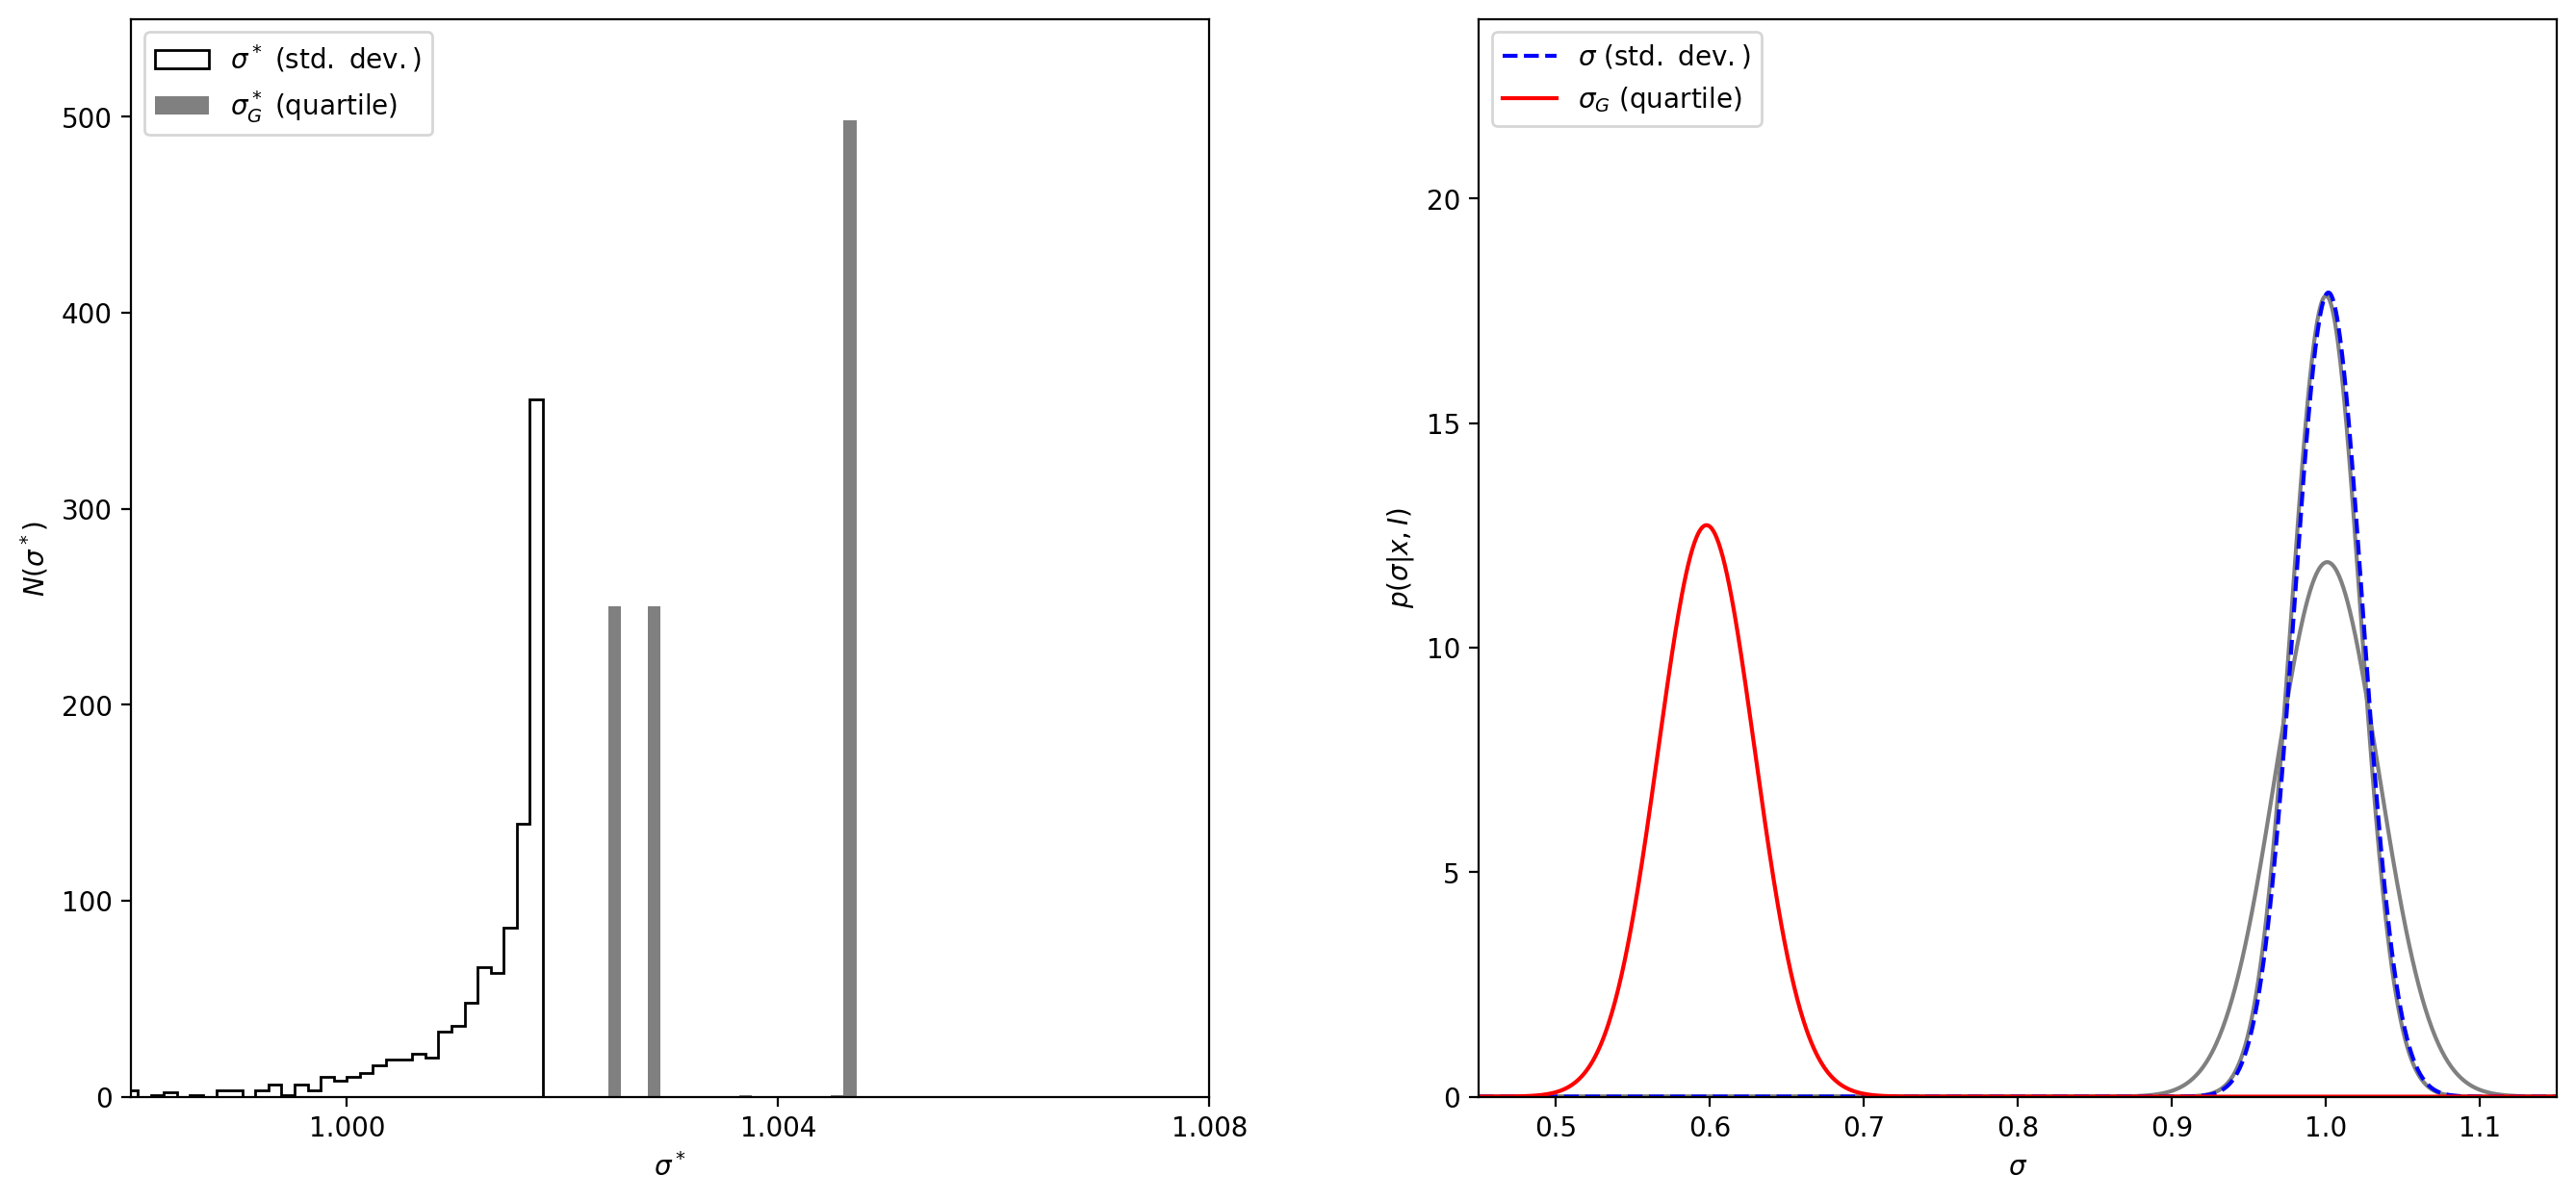

In [6]:
from astroML.resample import jackknife
from astroML.stats import sigmaG

m = 1000  # number of points
n = 10000  # number of bootstraps

np.random.seed(123)
data = norm(0, 1).rvs(m)

# mu1 (smooth stats)
mu1, sigma_mu1, mu1_raw = jackknife(data, np.std,                               #tuple unpacking
                                    kwargs=dict(axis=1, ddof=1),
                                    return_raw_distribution=True)

pdf1_theory = norm(1, 1. / np.sqrt(2 * (m - 1)))
pdf1_jackknife = norm(mu1, sigma_mu1)
print(mu1, sigma_mu1)

# mu2 (ranked-based stats)
mu2, sigma_mu2, mu2_raw = jackknife(data, sigmaG,                               #tuple unpacking
                                    kwargs=dict(axis=1),
                                    return_raw_distribution=True)
pdf2_theory = norm(data.std(), 1.06 / np.sqrt(m))
pdf2_jackknife = norm(mu2, sigma_mu2)
print(mu2, sigma_mu2)

print("mu_1 mean: %.2f +- %.2f" % (mu1, sigma_mu1))
print("mu_2 mean: %.2f +- %.2f" % (mu2, sigma_mu2))

fig = plt.figure(figsize=(15, 8))
fig.subplots_adjust(left=0.11, right=0.95, bottom=0.2, top=0.9,
                    wspace=0.25)

ax = fig.add_subplot(121)
ax.hist(mu1_raw, np.linspace(0.996, 1.008, 100),
        label=r'$\sigma^*\ {\rm (std.\ dev.)}$',
        histtype='stepfilled', fc='white', 
        ec='black', density=False)
ax.hist(mu2_raw, np.linspace(0.996, 1.008, 100),
        label=r'$\sigma_G^*\ {\rm (quartile)}$',
        histtype='stepfilled', fc='gray', 
        density=False)
ax.legend(loc='upper left', handlelength=2)

ax.xaxis.set_major_locator(plt.MultipleLocator(0.004))
ax.set_xlabel(r'$\sigma^*$')
ax.set_ylabel(r'$N(\sigma^*)$')
ax.set_xlim(0.998, 1.008)
ax.set_ylim(0, 550)

ax = fig.add_subplot(122)
x = np.linspace(0.45, 1.15, 1000)
ax.plot(x, pdf1_jackknife.pdf(x),
        color='blue', ls='dashed', 
        label=r'$\sigma\ {\rm (std.\ dev.)}$',
        zorder=2)
ax.plot(x, pdf1_theory.pdf(x), 
        color='gray', zorder=1)
ax.plot(x, pdf2_jackknife.pdf(x),
        color='red', 
        label=r'$\sigma_G\ {\rm (quartile)}$', 
        zorder=2)
ax.plot(x, pdf2_theory.pdf(x), 
        color='gray', zorder=1)
plt.legend(loc='upper left', handlelength=2)


ax.set_xlabel(r'$\sigma$')
ax.set_ylabel(r'$p(\sigma|x,I)$')
ax.set_xlim(0.45, 1.15)
ax.set_ylim(0, 24)

plt.show()

### Boot vs Jack


* **Boot**: works well for every statistics: mean, variance but also ranked based stats. Maps out the entire distribution since can be done N times with no restriction. It's computationally expensive and relies on random noise (thus not reproducable).

* **Jack**: doesn't work on ranked-based statistics. Doesn't map out the distribution of the estimator since it's limited by sample size. It's computationally cheaper and deterministic. It's built for bias correction of the estimator.

# Black-hole binary formation channels with gaussian mixtures.

### Introduction

Some events form in different astrophysical environments than others. You want to figure out how many of formation channels are at play.

The strategy here is to fit a Gaussian Mixture model: that is, my model is a sum of N gaussians each with mean $\mu_j$ and standard deviation $\sigma_j$
 and weight $\alpha_j$:

 $$p(x_i|\theta) = \sum_{i=1}^N \alpha_j \mathcal{N}(\mu_j, \sigma_j)$$

This depends on $3N - 1$ parameters (not $3N$ because the sum of the $\alpha_j$ must be unity to ensure that this is a probability, 1 constrain).

The dataset contains the masses of BH binaries.

### Tasks

- Load this file (np.load) and complete a quick exploration of the data. How many modes do you think you see?
- We'll use sklearn.mixture.GaussianMixture. You first need to define the model (instance of a class), and then train it on the data using the fit method (the data provided are already in the right numpy format!). This will output the trained model, which has various attributes.

- Complete the fit 10 times with $N = 1,...,10$ Gaussians.
  
$Note$: sklearn by default will use the so-called Expectation-Maximization algorithm, which is one of the many great things in data science we don't have time to study in this class.

- For each of this fits, compute the AIC (easy! It's an attribute of the trained model!). Plot $N$ vs AIC: which model is preferred?
- Plot the preferred solution on top of the input data. You should get a very nice fit!

In [7]:
import numpy as np
from matplotlib import pyplot as plt

file_path = 'formationchannels.npy'
data = np.load(file_path)

N=3000
set_x = np.linspace(-10,50, N)

print(f"The \"shape\" of the data set is: {data.shape}")

The "shape" of the data set is: (2950, 1)


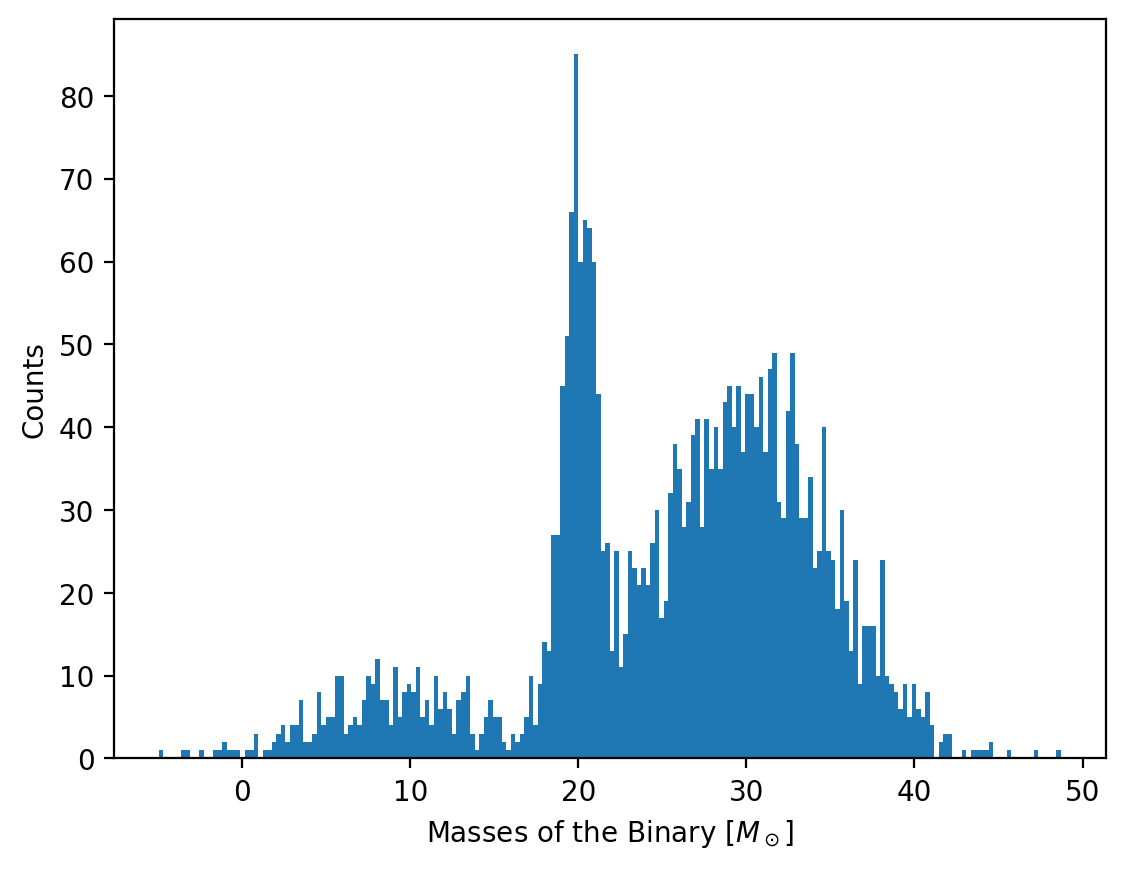

In [8]:
plt.hist(data, bins = 200)
plt.ylabel("Counts")
plt.xlabel(r"Masses of the Binary [$M_\odot$]")
plt.show()

### Gaussian Mixture

In [9]:
from sklearn.mixture import GaussianMixture as gm

def likelihood(x, mu, sigma):
    norm = 1/np.sqrt(2 * np.pi * sigma**2)
    exp = np.exp(-(x - mu)**2/(2*sigma**2))
    p = norm * exp
    return p

#### TEST 1
Try with 3 gaussians

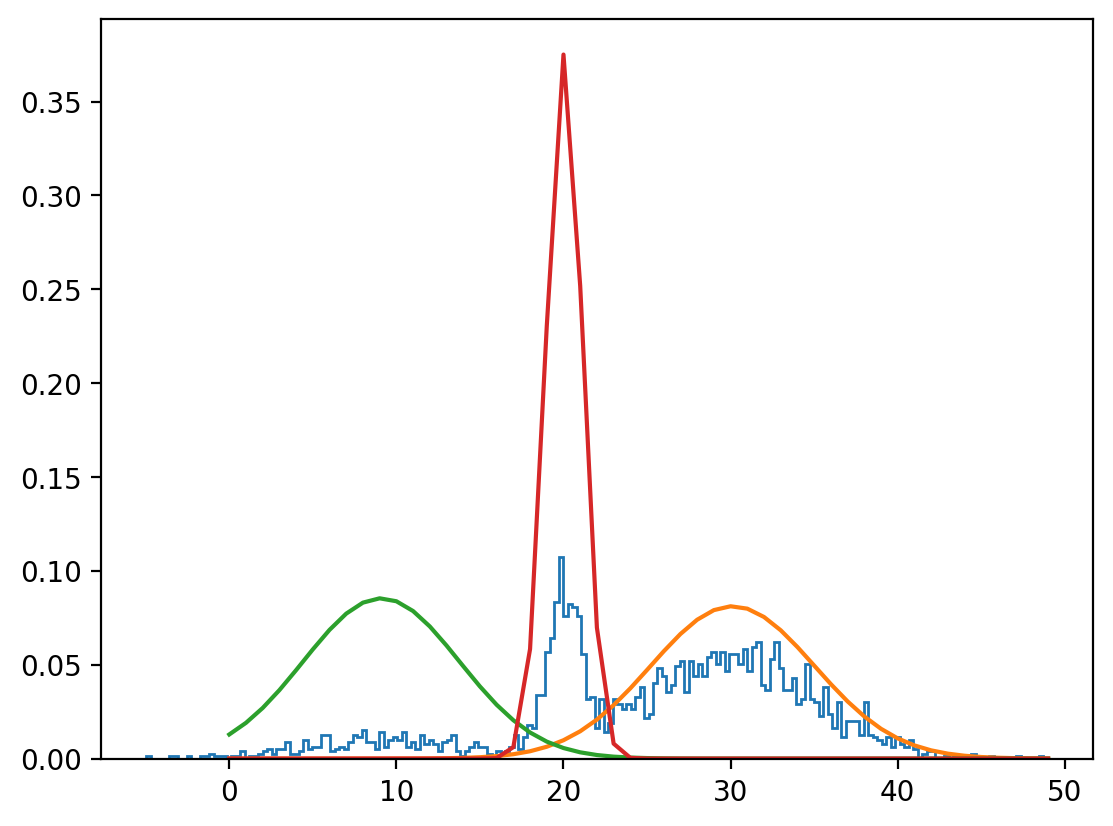

Parametri del Gaussian Mixture Model
Componente 1:
  Peso (w)    : 0.6698
  Media (mu)  : 30.1175
  Varianza    : 24.1637
  Dev. St. (s): 4.9157

Componente 2:
  Peso (w)    : 0.1163
  Media (mu)  : 9.0956
  Varianza    : 21.8276
  Dev. St. (s): 4.6720

Componente 3:
  Peso (w)    : 0.2139
  Media (mu)  : 20.0504
  Varianza    : 1.1289
  Dev. St. (s): 1.0625



In [15]:
gm1 = gm(n_components=3).fit(data)
set_x = np.arange(0,50)
gaussians = np.array([likelihood(set_x, mu_i, np.sqrt(sigma_i)) for mu_i, sigma_i in zip(gm1.means_.ravel(), gm1.covariances_.ravel())])

plt.hist(data, bins = 200, histtype = 'step', density = True)
plt.plot(set_x, gaussians.T)
plt.show()

pesi = gm1.weights_
medie = gm1.means_.ravel()
varianze = gm1.covariances_.ravel()

print("Parametri del Gaussian Mixture Model")
for i in range(gm1.n_components):
    print(f"Componente {i+1}:")
    print(f"  Peso (w)    : {pesi[i]:.4f}")
    print(f"  Media (mu)  : {medie[i]:.4f}")
    print(f"  Varianza    : {varianze[i]:.4f}")
    print(f"  Dev. St. (s): {np.sqrt(varianze[i]):.4f}\n")

#### TEST 2
try with different number of gaussians

In [17]:
n = range(1, 11)
gms = np.array([gm(int(i)).fit(data) for i in n])
many_gaus = []

print("Parametri dei Gaussian Mixture Models")

# Iteriamo su ogni modello GMM salvato nella tua lista 'gms'
for gmi in gms:
    n_comp = gmi.n_components
    print(f"MODELLO CON {n_comp} COMPONENTI")
    
    pesi = gmi.weights_
    medie = gmi.means_.ravel()
    varianze = gmi.covariances_.ravel()
    
    # 1. Stampa dei parametri
    for i in range(n_comp):
        print(f"  Componente {i+1}:")
        print(f"    Peso (w)    : {pesi[i]:.4f}")
        print(f"    Media (mu)  : {medie[i]:.4f}")
        print(f"    Varianza    : {varianze[i]:.4f}")
        print(f"    Dev. St. (s): {np.sqrt(varianze[i]):.4f}\n")
        
    # 2. Calcolo e salvataggio delle curve in many_gaus!
    plot = np.array([
        likelihood(set_x, mu_i, np.sqrt(sigma_i)) * w_i 
        for mu_i, sigma_i, w_i in zip(medie, varianze, pesi)
    ])
    many_gaus.append(plot)


Parametri dei Gaussian Mixture Models
MODELLO CON 1 COMPONENTI
  Componente 1:
    Peso (w)    : 1.0000
    Media (mu)  : 25.5201
    Varianza    : 70.8877
    Dev. St. (s): 8.4195

MODELLO CON 2 COMPONENTI
  Componente 1:
    Peso (w)    : 0.4473
    Media (mu)  : 19.8960
    Varianza    : 66.4654
    Dev. St. (s): 8.1526

  Componente 2:
    Peso (w)    : 0.5527
    Media (mu)  : 30.0714
    Varianza    : 28.1547
    Dev. St. (s): 5.3061

MODELLO CON 3 COMPONENTI
  Componente 1:
    Peso (w)    : 0.3639
    Media (mu)  : 25.0961
    Varianza    : 23.7711
    Dev. St. (s): 4.8756

  Componente 2:
    Peso (w)    : 0.3491
    Media (mu)  : 19.7318
    Varianza    : 86.6158
    Dev. St. (s): 9.3068

  Componente 3:
    Peso (w)    : 0.2870
    Media (mu)  : 33.0989
    Varianza    : 13.0872
    Dev. St. (s): 3.6176

MODELLO CON 4 COMPONENTI
  Componente 1:
    Peso (w)    : 0.2340
    Media (mu)  : 20.0924
    Varianza    : 1.3137
    Dev. St. (s): 1.1462

  Componente 2:
    Peso (w)  

Valori nella lista n: range(1, 11)
Modelli salvati in many_gaus: 10


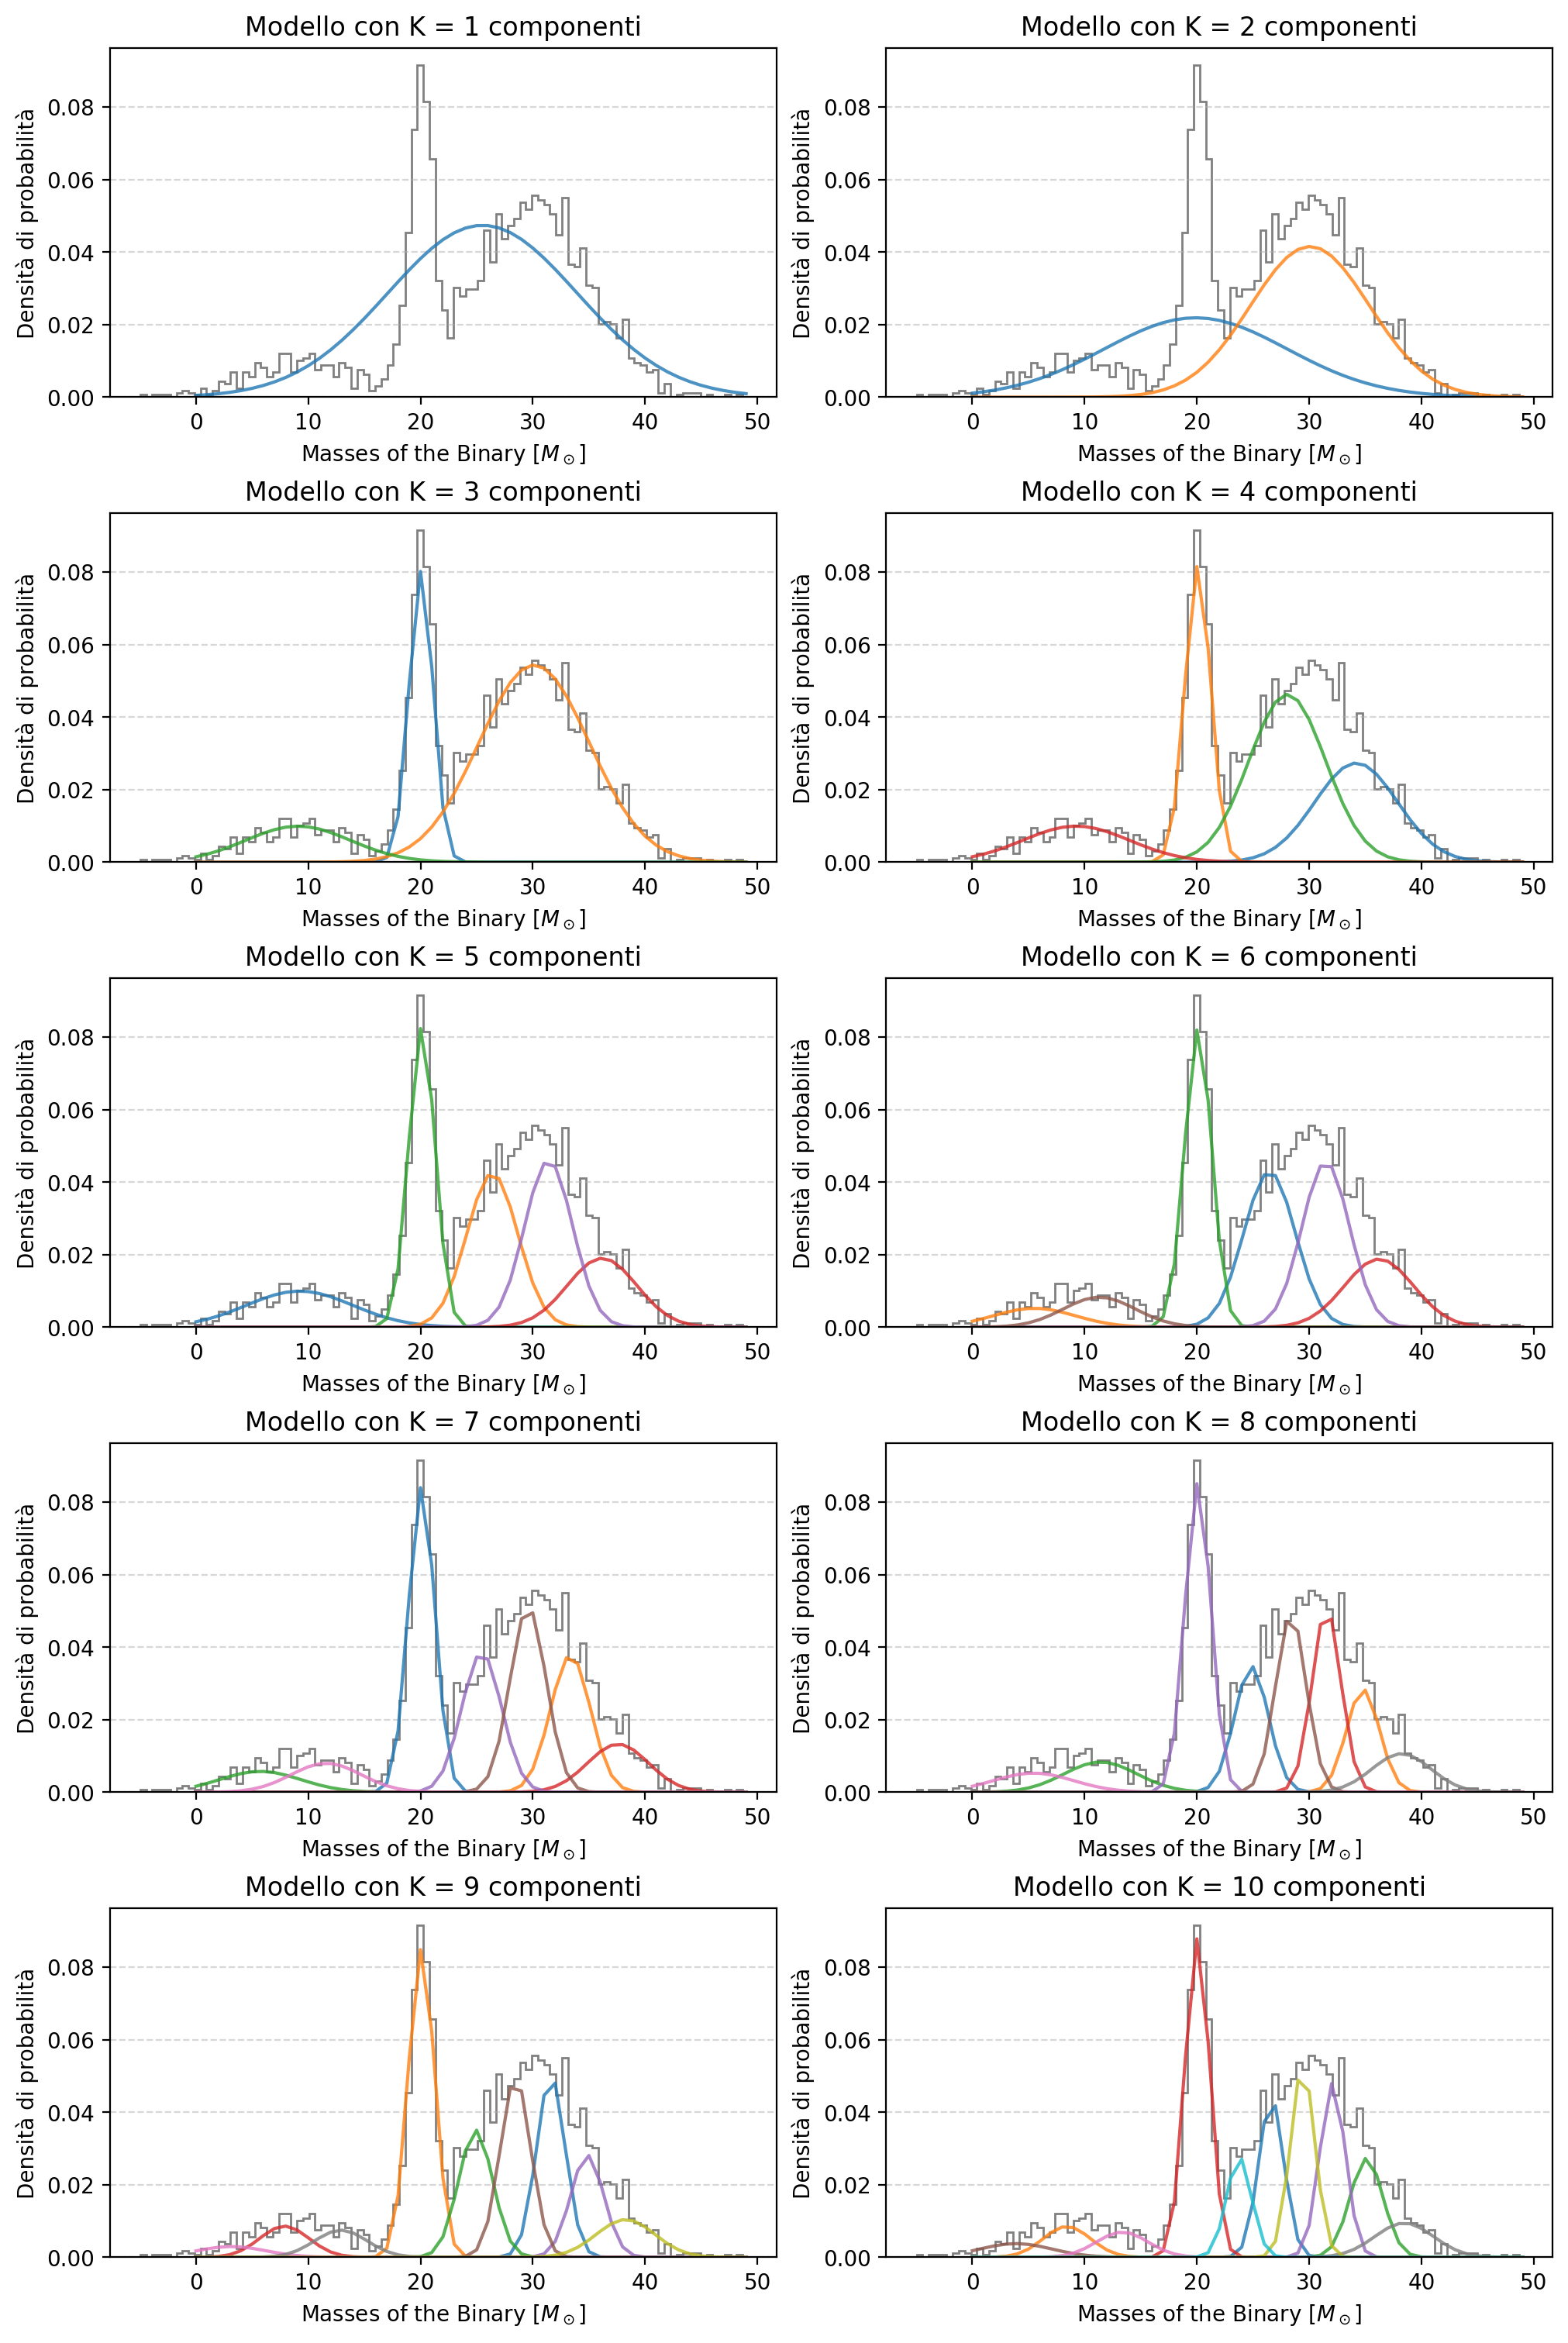

In [12]:
print(f"Valori nella lista n: {n}")
print(f"Modelli salvati in many_gaus: {len(many_gaus)}")
fig, axes = plt.subplots(5, 2, figsize=(10, 15), constrained_layout=True)
axes = axes.flatten() # Trasformiamo la matrice di assi in una lista piatta

for i, ax in enumerate(axes):
    # Controllo di sicurezza: se abbiamo esaurito i modelli, nascondiamo l'asse vuoto
    if i >= len(many_gaus):
        ax.set_visible(False)
        continue
        
    gaus_model = many_gaus[i]
    
    # 1. Plot istogramma sui dati (sullo sfondo)
    ax.hist(data, bins=100, histtype='step', density=True, color='gray', label='Dati', zorder=1)
    
    # 2. Plot delle singole gaussiane
    # Usiamo alpha per renderle leggermente trasparenti e non coprire l'istogramma
    ax.plot(set_x, gaus_model.T, alpha=0.8, zorder=2)
    
    # Il titolo prende il numero di componenti dalla lista n
    ax.set_title(f"Modello con K = {n[i]} componenti")
    ax.set_xlabel(r"Masses of the Binary [$M_\odot$]")
    ax.set_ylabel("Densità di probabilità")
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

### Akaike Information Criterion (AIC)

The **AIC** is an estimator of relative quality of statistical models for a given set of data. It is based on the principle of parsimony: it seeks the best compromise between the goodness-of-fit and the simplicity of the model, introducing a penalty term to avoid **overfitting**.

The mathematical definition is:

$$\text{AIC} = 2k - 2\ln(\hat{L})$$

Where:
* $k$: is the number of estimated parameters in the model (representing the penalty for complexity).
* $\hat{L}$: is the maximum value of the likelihood function for the model.

**Decision Rule:** Given a set of candidate models, the preferred model is the one with the **minimum AIC value**. The $-2\ln(\hat{L})$ term rewards models that fit the data well, while the $2k$ term penalizes unnecessarily complex models.

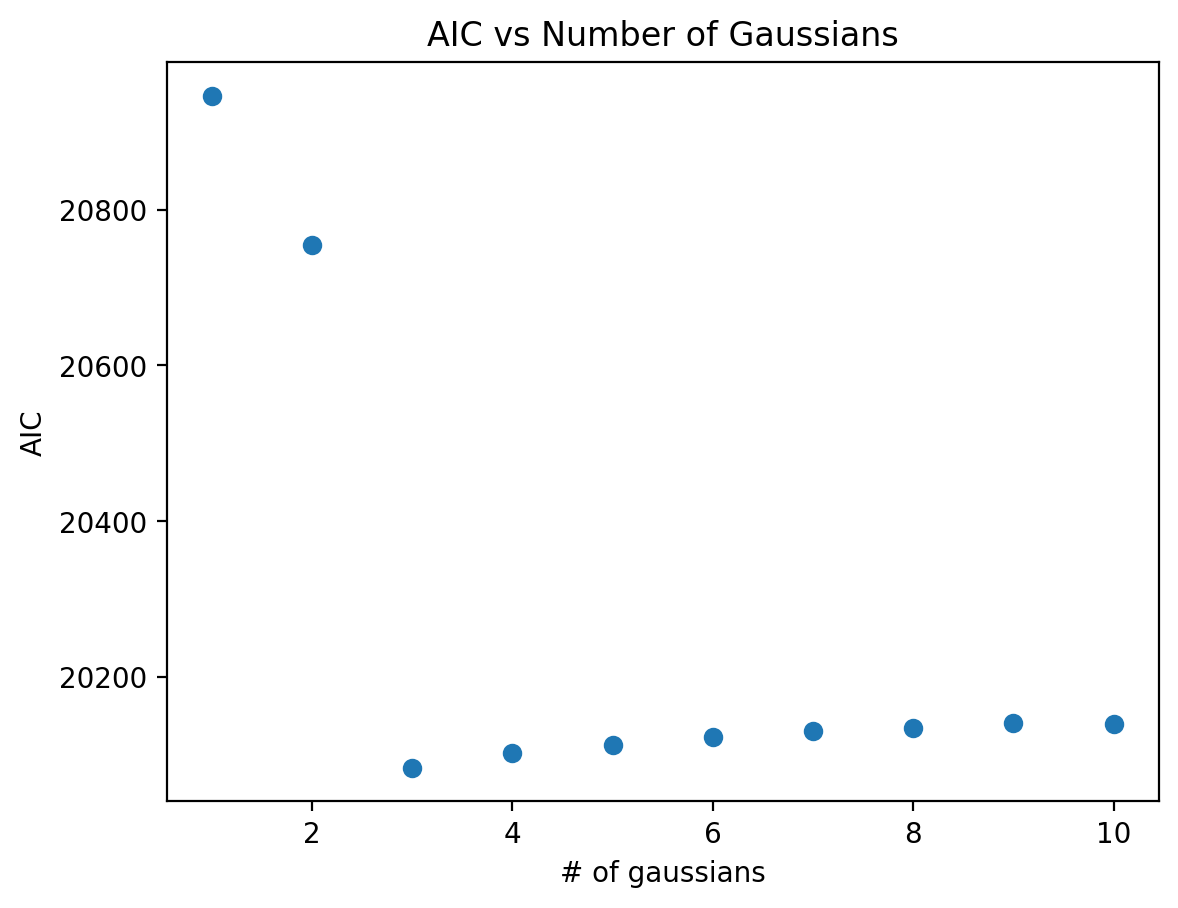

In [13]:
aics = np.array([gmi.aic(data) for gmi in gms])

plt.scatter(n, aics)
plt.title("AIC vs Number of Gaussians")
plt.ylabel("AIC")
plt.xlabel("# of gaussians")
plt.show()